                 ┌──────────────────┐
                 │  Internal Model   │
                 └────────┬─────────┘
                          │
                          ▼
                    Prediction
                          │
                          ▼
                 ┌──────────────────┐
                 │   Environment    │
                 └────────┬─────────┘
                          │
                          ▼
                   Sensory Input
                          │
                          ▼
              ┌──────────────────────┐
              │       Compare        │
              │ Prediction vs Input  │
              └──────────┬───────────┘
                         │
                         ▼
                 Prediction Error
                         │
              ┌──────────┴──────────┐
              │                     │
              ▼                     ▼
        Update Belief          Take Action
              │                     │
              ▼                     ▼
        Internal Model         Environment
              │                     │
              └──────────┬──────────┘
                         │
                         ▼
                  New Prediction

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

s_true = 2.0

A = 1.0
sigma_o = 0.5
sigma_s = 1.0

mu_prior = 0.0
var_prior = sigma_s ** 2

o = A * s_true + np.random.normal(0, sigma_o)

print("True hidden state:", s_true)
print("Observed sensory input:", round(o, 3))

True hidden state: 2.0
Observed sensory input: 2.248


In [9]:
Pi_o = 1 / sigma_o**2
Pi_s = 1 / var_prior

Pi_post = Pi_s + A**2 * Pi_o
var_post = 1 / Pi_post

mu_post = var_post * (
    Pi_s * mu_prior +
    A * Pi_o * o
)

print("Prior mean:", mu_prior)
print("Observation:", round(o, 3))
print("Posterior mean:", round(mu_post, 3))
print("Posterior variance:", round(var_post, 3))

Prior mean: 0.0
Observation: 2.248
Posterior mean: 1.799
Posterior variance: 0.2


In [12]:
samples = np.random.normal(
    mu_post,
    np.sqrt(var_post),
    10000
)

log_q = (
    -0.5 * np.log(2 * np.pi * var_post)
    - (samples - mu_post)**2 / (2 * var_post)
)

log_p_s = (
    -0.5 * np.log(2 * np.pi * var_prior)
    - (samples - mu_prior)**2 / (2 * var_prior)
)

log_p_o_given_s = (
    -0.5 * np.log(2 * np.pi * sigma_o**2)
    - (o - A * samples)**2 / (2 * sigma_o**2)
)

F = np.mean(
    log_q -
    log_p_s -
    log_p_o_given_s
)

print("Variational Free Energy:", round(F, 5))

Variational Free Energy: 3.05255


In [13]:
mu = -2.0
learning_rate = 0.05

free_energy_history = []
belief_history = []

for step in range(100):

    predicted_o = A * mu

    sensory_error = o - predicted_o
    prior_error = mu - mu_prior

    sensory_term = A * Pi_o * sensory_error
    prior_term = Pi_s * prior_error

    gradient = prior_term - sensory_term

    mu = mu - learning_rate * gradient

    F = (
        0.5 * Pi_s * prior_error**2
        + 0.5 * Pi_o * sensory_error**2
    )

    belief_history.append(mu)
    free_energy_history.append(F)

print("True state:", s_true)
print("Final inferred state:", round(mu, 3))

True state: 2.0
Final inferred state: 1.799


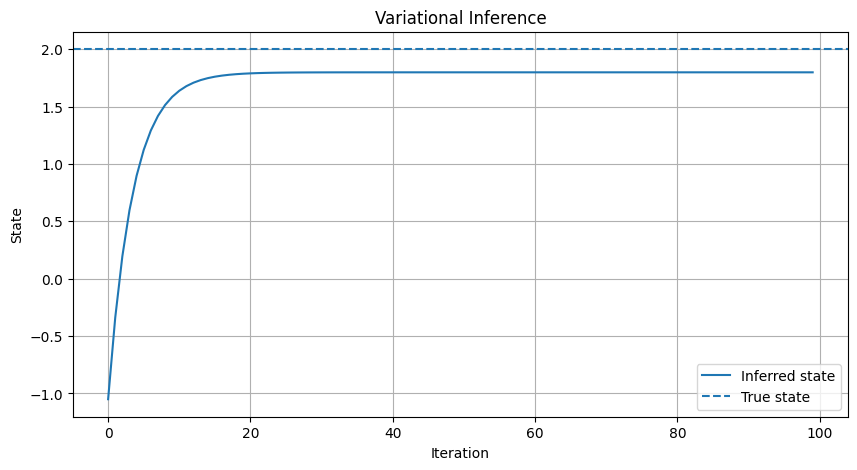

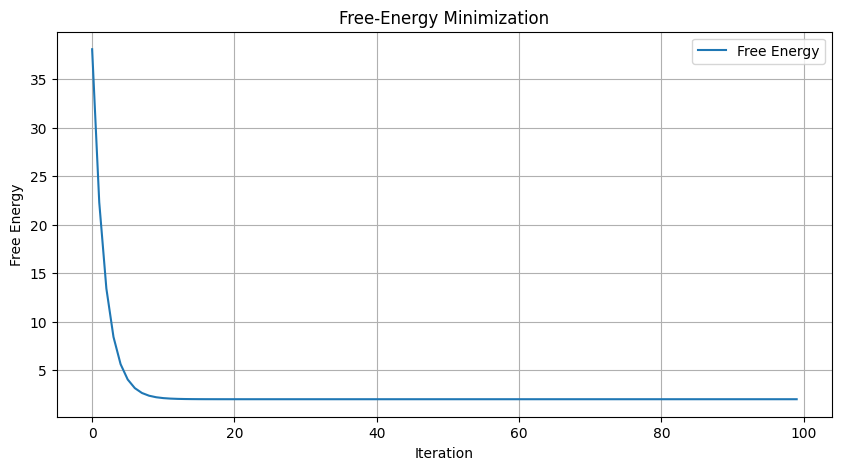

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    belief_history,
    label="Inferred state"
)

plt.axhline(
    s_true,
    linestyle="--",
    label="True state"
)

plt.xlabel("Iteration")
plt.ylabel("State")
plt.title("Variational Inference")
plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    free_energy_history,
    label="Free Energy"
)

plt.xlabel("Iteration")
plt.ylabel("Free Energy")
plt.title("Free-Energy Minimization")
plt.legend()
plt.grid(True)

plt.show()

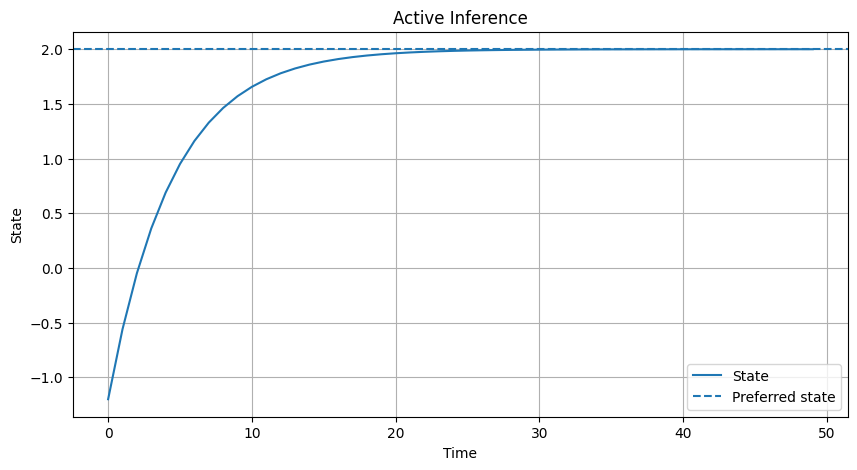

In [15]:
preferred_o = 2.0
state = -2.0

action_rate = 0.2

state_history = []
action_history = []
error_history = []

for step in range(50):

    observation = state

    error = observation - preferred_o

    action = -action_rate * error

    state = state + action

    state_history.append(state)
    action_history.append(action)
    error_history.append(error)


plt.figure(figsize=(10, 5))

plt.plot(
    state_history,
    label="State"
)

plt.axhline(
    preferred_o,
    linestyle="--",
    label="Preferred state"
)

plt.xlabel("Time")
plt.ylabel("State")
plt.title("Active Inference")
plt.legend()
plt.grid(True)

plt.show()